## Stat 488 - Project 1
Author: Mason Holcombe 

### Introduction

In this project, I analyze the multivariate distribution of various demographic related questions across many stratifications. The data which I will be analyzing is percentages of populations which fall under a certain question. There are 9 specific questions regarding obesity, physical activity, and diet. The questions are as follows:

1. Percent of adults aged 18 years and older who have obesity
2. Percent of adults aged 18 years and older who have an overweight classification
3. Percent of adults who achieve at least 150 minutes per week of moderate-intensity aerobic physical activity or 75 minutes per week of vigorous-intensity aerobic activity (or an equivalent combination)
4. Percent of adults who achieve at least 150 minutes per week of moderate-intensity aerobic physical activity or 75 minutes per week of vigorous-intensity aerobic physical activity (or an equivalent combination) and engage in muscle-strengthening activities on 2 or more days per week
5. Percent of adults who achieve more than 300 minutes per week of moderate-intensity aerobic physical activity or 150 minutes per week of vigorous-intensity aerobic activity (or an equivalent combination)
6. Percent of adults who engage in muscle-strengthening activities on 2 or more days per week
7. Percent of adults who engage in no leisure-time physical activity
8. Percent of adults who report consuming fruit less than one time daily
9. Percent of adults who report consuming vegetables less than one time daily

This multivariate analysis will provide insight into demographic differences & similarities in health related data and could be used to direct resources for specific populations.

### Details of Methods Used

The dataset is reported from the Behavioral Risk Factor Surveillance System under the Department of Health & Human Services (HHS). For each group analysis, the data waas aggregated and reshaped into a wide format as opposed to a long format with the question percentages along the row. Having the question percentages along the columns yields $p=9$ variables in the multivaraite analysis.

#### Assessing Multivariate Normality

To assess the assumption that 

<center>

$X \sim N_p(\mu, \Sigma)$

</center>

Mahalanobis distances were calculated for each group observation: 

<center>

$D_i^2 = (x_i - \bar{x})^T S^{-1} (x_i - \bar{x})$

</center>

Under this assumption

<center>

$D_i^2 \sim \chi^2_p$

</center>

My observed quantile values were than compared with the theoretical $\chi^2_p$ quantiles to assess this multivariate normality assumption. 

#### MANOVA

To compare same-stratification (Income/Ethnicity/Age/etc.) groups simultaneously, multivariate analysis of variance (MANOVA) was performed across sets of variables. MANOVA assumes the null hypothesis of 

<center>

$H_0 : \mu_1 = \mu_2 = \cdots = \mu_g$

</center>

where g represents the number of groups within the variable. The test was done using Wilk's Lambda statistic:

<center>

$\Lambda = \frac{|W|}{|W + B|}$

</center>

with 
- $W = $ within group sum of squares and cross products (SSCP) matrix
- $B = $ between group sum of squares and cross products (SSCP) matrix

Wilk's Lambda was then converted via Bartlett's correction:
<center>

$\chi^2 = -\left(N - 1 - \frac{p + g}{2}\right)\ln(\Lambda)$

</center>

and compared to a $\chi^2$ distribution with $\text{df} = p(g-1)$ at significance level $\alpha = 0.05$. 

#### Software
Analysis was performed in Python, mostly using the pandas library. Scipy was also used for distribution functions similar to R.

### Findings/Conclusions

I began by assessing multivariate normality across all states in the dataset. After cleaning the data into an $ n \times p $ matrix for Mahalanobis distances, I calculated both these distances and the theoretical $\chi^2_p$ quantiles. In **Plot 1**, we notice a large majority of these states fall along/near the 45 degree angle line. There are two main things I see in this plot. 
1) Many of the states are slighly below the 45 degree angle line, this is indicative of generally good distributional fit, but slightly smaller in magnitude relative to the theoretical quantiles. 
2) I notice 3 states far off of the 45 degree angle line. These states are the District of Columbia, Puerto Rico, and the Virgin Islands. This suggests these states are multivariate outliers. They clearly differ in population, infrastructure, etc than many normal states and this is seen statistically as well.

I next wanted to conduct MANOVA on various stratifications to determine similarities & differences among groups. I chose to compare Income, Age (years), and Education across the health, physical activity, and diet related variables. In **Table 1** we see *all* combinations of these stratifications & variable groups statistically signifiacnt multivariate differences in means. Although these results are significant under $\alpha = 0.05$, the Age stratification across diet related variables had the largest Wilk's lambda, indicating the least multivariate seperation in diet variables among age groups. Similarly, physical related variables exhibited the highest Wilk's lambda, indicating the strongest multivariate seperation between groups.

In addition to the Wilk's lambda calculations, I also plotted in **Plot 2** the appropriate $\chi^2$ distribution with the critical value and the observed bartlett corrected statistic. You can notice all of these are to the right of the critical value, indicating a < 0.05 p-value and statistically significant results.

### Recommendations/Caveats

This data is quite granular in the fact it can be analyzed at many different levels provided in the dataset. A caveat that may require further analysis or data is the fact that this data is given as percentages. Although I determined multivariate normality across this data, i'd be interested in the source data to determine similar trends.

I would recommend either removing or treading carefulyl when analyzing the multivariate data related to the District of Columbia, Puerto Rico, or the Virgin Islands as these states/territories were clear extreme observations and multivarite outliers, based on Mahalanobis quantiles to theoretical $\chi^2$.

### Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2

In [2]:
health = pd.read_csv('health/health.csv')
df = health

C:\Users\mason\AppData\Local\Temp\ipykernel_23492\1968095123.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  health = pd.read_csv('health/health.csv')


In [3]:
question_mapping = {
    "Percent of adults aged 18 years and older who have an overweight classification": "overweight",
    "Percent of adults aged 18 years and older who have obesity": "Obesity",
    "Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)": "Low Intense activity",
    "Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic physical activity (or an equivalent combination) and engage in muscle-strengthening activities on 2 or more days a week": "Intense activity",
    "Percent of adults who achieve more than 300 minutes a week of moderate-intensity aerobic physical activity or 150 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)": "Moderate activity",
    "Percent of adults who engage in muscle-strengthening activities on 2 or more days a week": "Muscle activity",
    "Percent of adults who engage in no leisure-time physical activity": "Physical activity",
    "Percent of adults who report consuming fruit less than one time daily": "<1 Fruit",
    "Percent of adults who report consuming vegetables less than one time daily": "<1 Veg"
}

health_related = ["overweight", "Obesity"]
physical_related = ["Low Intense activity", "Intense activity", "Moderate activity", "Muscle activity", "Physical activity"]
diet_related = ["<1 Fruit", "<1 Veg"]

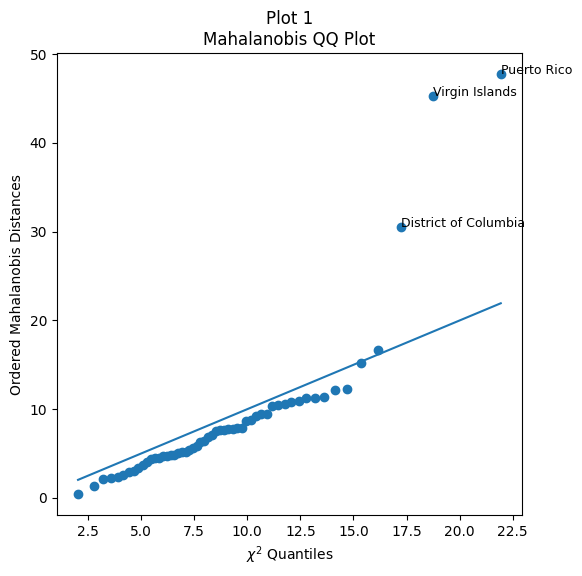

In [9]:
#### Plot 1 ####
df_filtered = df[["LocationDesc", "Question", "Data_Value"]]
df_wide = df_filtered.pivot_table(
    index="LocationDesc",
    columns="Question",
    values="Data_Value",
    aggfunc="mean"
)

df_wide = df_wide.dropna()
df_wide.columns = list(question_mapping.values())

X = df_wide.values

mean = np.mean(X, axis=0)
cov = np.cov(X.T)
inv_cov = np.linalg.inv(cov)

D = np.array([(x-mean).T @ inv_cov @ (x-mean) for x in X])

n = len(D)
p = X.shape[1]

sorted_idx = np.argsort(D)
sorted_D = D[sorted_idx]

chi_vals = chi2.ppf((np.arange(1,n+1)-0.5)/n, df=p)

plt.figure(figsize=(6,6))
plt.scatter(chi_vals, sorted_D)
plt.plot(chi_vals, chi_vals)

for i in range(n-3, n):
    original_index = sorted_idx[i]
    label = df_wide.iloc[original_index].name
    plt.text(chi_vals[i], sorted_D[i], label, fontsize=9)

plt.xlabel(r"$\chi^2$ Quantiles")
plt.ylabel("Ordered Mahalanobis Distances")
plt.title("Plot 1\nMahalanobis QQ Plot")
plt.show()

In [ ]:
def calc_manova(df, stratification, variable_list):
    df_filtered = df[["LocationDesc", "YearStart", stratification, "Question", "Data_Value"]]
    df_wide = df_filtered.pivot_table(
        index=["LocationDesc", "YearStart", stratification],
        columns="Question",
        values="Data_Value",
        aggfunc="mean"
    )

    df_wide = df_wide.dropna()
    df_wide.columns = list(question_mapping.values())

    df_wide = df_wide.reset_index()
    groups = df_wide.groupby(stratification)

    N = len(df_wide)
    g = df_wide[stratification].nunique()
    p = len(variable_list)

    overall_mean = df_wide[variable_list].mean().values

    W = np.zeros((p,p))
    B = np.zeros((p,p))

    for name, group in groups:
        
        X = group[variable_list].values
        n_i = X.shape[0]
        
        mean_i = X.mean(axis=0)
        
        for x in X:
            diff = (x - mean_i).reshape(p,1)
            W += diff @ diff.T
        
        diff_mean = (mean_i - overall_mean).reshape(p,1)
        B += n_i * diff_mean @ diff_mean.T

    T = W + B

    wilks_lambda = np.linalg.det(W) / np.linalg.det(T)

    # Bartlett correction
    bartlett_stat = -(n-1 - ((p+g)/2)) * np.log(wilks_lambda)
    chi2_crit = chi2.ppf(0.95, df=p*(g-1))

    p_val = 1 - chi2.cdf(bartlett_stat, p*(g-1))

    return {
        "wilks_lambda": wilks_lambda,
        "bartlett_stat": bartlett_stat,
        "chi2_crit": chi2_crit,
        "p_val": p_val
    }

In [15]:
#### Table 1 ####
stratifications = ["Income", "Age(years)", "Education"]
variables = {
    "health_related": health_related,
    "physical_related": physical_related,
    "diet_related": diet_related
}

results = []
for strat in stratifications:
    for var_name, var_cols in variables.items():
        
        res = calc_manova(df, strat, var_cols)
        
        results.append({
            "stratification": strat,
            "variable_group": var_name,
            "wilks_lambda": res["wilks_lambda"],
            "bartlett_stat": res["bartlett_stat"],
            "chi2_crit": res["chi2_crit"],
            "p_value": res["p_val"]
        })

results_df = pd.DataFrame(results)
results_df["p_value"] = results_df["p_value"].map(lambda x: f"{x:.6f}")

print(results_df)

  stratification    variable_group  wilks_lambda  bartlett_stat  chi2_crit  \
0         Income    health_related      0.356625      51.037950  21.026070   
1         Income  physical_related      0.251067      66.337609  43.772972   
2         Income      diet_related      0.407012      44.496223  21.026070   
3     Age(years)    health_related      0.120643     105.745824  18.307038   
4     Age(years)  physical_related      0.093771     114.794821  37.652484   
5     Age(years)      diet_related      0.622603      23.692322  18.307038   
6      Education    health_related      0.524183      32.941675  12.591587   
7      Education  physical_related      0.144347      95.808837  24.995790   
8      Education      diet_related      0.279377      65.034916  12.591587   

    p_value  
0  0.000001  
1  0.000148  
2  0.000013  
3  0.000000  
4  0.000000  
5  0.008460  
6  0.000011  
7  0.000000  
8  0.000000  


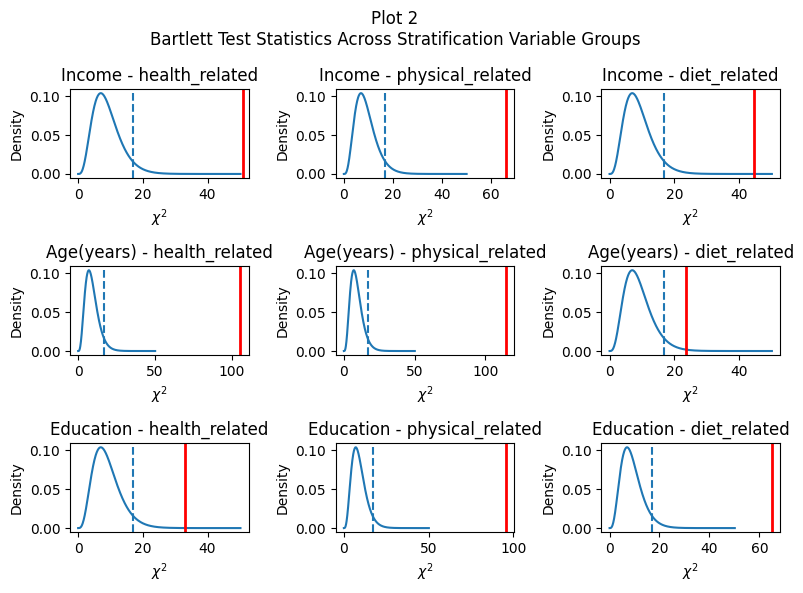

In [21]:
#### Plot 2 ####
fig, axes = plt.subplots(3, 3, figsize=(8,6))
axes = axes.flatten()

for i, (_, row) in enumerate(results_df.iterrows()):

    g = len(variables[var_name])
    df_chi = p * (g - 1)

    x = np.linspace(0, chi2.ppf(0.9999999, df_chi), 500)
    y = chi2.pdf(x, df_chi)

    ax = axes[i]

    # Chi-square curve
    ax.plot(x, y)

    # Critical value
    crit = chi2.ppf(0.95, df_chi)
    ax.axvline(crit, linestyle='--', label="Critical Value")

    # Bartlett statistic
    ax.axvline(row["bartlett_stat"], linewidth=2, label="Bartlett Stat", c="red")

    ax.set_title(f"{row['stratification']} - {row['variable_group']}")
    ax.set_xlabel(r"$\chi^2$")
    ax.set_ylabel("Density")

fig.suptitle("Plot 2\nBartlett Test Statistics Across Stratification Variable Groups")
plt.tight_layout()
plt.show()